In [1]:
pip install pandas openpyxl scikit-learn matplotlib seaborn scipy numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
!cd /home/qc && tar -xzf mpcabd-python-arabic-reshaper-v3.0.1-0-ged35ce4.tar.gz

In [16]:
import shutil
import site
import glob
import os

# پیدا کردن مسیر اکسترکت شده
extracted_dirs = glob.glob('/home/qc/mpcabd-python-arabic-reshaper*')
target_dir = site.getsitepackages()[0]

for d in extracted_dirs:
    source_pkg = os.path.join(d, 'arabic_reshaper')
    if os.path.isdir(source_pkg):
        dest_pkg = os.path.join(target_dir, 'arabic_reshaper')
        if os.path.exists(dest_pkg):
            shutil.rmtree(dest_pkg)
        shutil.copytree(source_pkg, dest_pkg)
        print(f"✅ پوشه arabic_reshaper با موفقیت کپی شد در: {dest_pkg}")
        break


✅ پوشه arabic_reshaper با موفقیت کپی شد در: /home/qc/venvs/spark/lib/python3.12/site-packages/arabic_reshaper


In [17]:
import arabic_reshaper
print("🎉 تبریک امین جان! arabic_reshaper با موفقیت لود شد.")


🎉 تبریک امین جان! arabic_reshaper با موفقیت لود شد.


In [19]:
import os
import arabic_reshaper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# مسیر فونت Tahoma یا Arial ویندوز در WSL
font_path = "/mnt/c/Windows/Fonts/tahoma.ttf"

# اگر فونت بی نازنین یا یکان داری هم می‌تونی مسیرش رو بدی
if os.path.exists(font_path):
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    print("✅ فونت Tahoma ویندوز با موفقیت روی Matplotlib ست شد!")


✅ فونت Tahoma ویندوز با موفقیت روی Matplotlib ست شد!


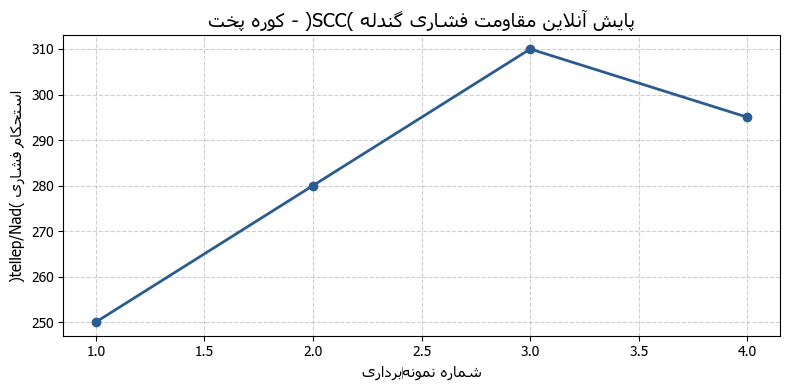

In [24]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arabic_reshaper
import os

# ۱. ست کردن فونت خوانای فارسی از ویندوز
font_path = "/mnt/c/Windows/Fonts/tahoma.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Tahoma'

# ۲. تابع معکوس‌ساز هوشمند
def farsi(text):
    reshaped = arabic_reshaper.reshape(text)
    return reshaped[::-1]

# ۳. تست رسم یک نمودار نمونه
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3, 4], [250, 280, 310, 295], marker='o', color='#2b5c8f', lw=2)

plt.title(farsi("پایش آنلاین مقاومت فشاری گندله (CCS) - کوره پخت"), fontsize=14, fontweight='bold')
plt.xlabel(farsi("شماره نمونه‌برداری"), fontsize=11)
plt.ylabel(farsi("استحکام فشاری (daN/pellet)"), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [26]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.interpolate import griddata
from sklearn.ensemble import RandomForestRegressor
import arabic_reshaper

# ==========================================
# ۰. پیکربندی فونت و تابع اصلاح متن فارسی
# ==========================================
# جستجوی فونت تاهوما یا فونت‌های فارسی استاندارد ویندوز در WSL
font_candidates = [
    "/mnt/c/Windows/Fonts/tahoma.ttf",
    "/mnt/c/Windows/Fonts/segoeui.ttf",
    "/mnt/c/Windows/Fonts/arial.ttf",
    "/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
]

chosen_font = None
for f_path in font_candidates:
    if os.path.exists(f_path):
        fm.fontManager.addfont(f_path)
        prop = fm.FontProperties(fname=f_path)
        chosen_font = prop.get_name()
        plt.rcParams['font.family'] = chosen_font
        print(f"✅ فونت فعال شد: {chosen_font} ({f_path})")
        break

plt.rcParams['axes.unicode_minus'] = False  # برای نمایش صحیح علامت منفی (-)

def fa(text):
    """اصلاح حروف جدا شده و معکوس کردن جهت برای نمایش بی‌نقص در Matplotlib"""
    if not text:
        return text
    reshaped = arabic_reshaper.reshape(str(text))
    return reshaped[::-1]

# ==========================================
# ایجاد دایرکتوری خروجی‌ها در صورت عدم وجود
# ==========================================
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# ۱. بارگذاری فایل اکسل کارخانه
file_path = "/home/qc/Pellet_Induration_QC_Chapter5_Dataset.xlsx"
df_process = pd.read_excel(file_path, sheet_name="Fact_Process_Hourly", parse_dates=["Timestamp"])
df_qc = pd.read_excel(file_path, sheet_name="Fact_QC_Samples", parse_dates=["Sample_Timestamp"])

# مرتب‌سازی زمانی دقیق
df_process = df_process.sort_values("Timestamp").reset_index(drop=True)
df_qc = df_qc.sort_values("Sample_Timestamp").reset_index(drop=True)

# ۲. تعریف تابع استخراج میانگین شرایط کوره در پنجره [t - 2h, t)
def extract_process_window(t_sample):
    t_start = t_sample - pd.Timedelta(hours=2)
    window = df_process[(df_process["Timestamp"] >= t_start) & (df_process["Timestamp"] < t_sample)]

    if len(window) == 0:
        return pd.Series(dtype=float)

    return pd.Series({
        "Temp_UDD_C": window["Temp_UDD_C"].mean(),
        "Temp_DDD_C": window["Temp_DDD_C"].mean(),
        "Temp_PH_C": window["Temp_PH_C"].mean(),
        "Temp_Firing_C": window["Temp_Firing_C"].mean(),
        "Temp_AfterFiring_C": window["Temp_AfterFiring_C"].mean(),
        "Temp_Cooling_C": window["Temp_Cooling_C"].mean(),
        "Windbox_Avg_DP_kPa": window["Windbox_Avg_DP_kPa"].mean(),
        "O2_Firing_pct": window["O2_Firing_pct"].mean(),
        "Bed_Height_mm": window["Bed_Height_mm"].mean(),
        "Pallet_Speed_mpm": window["Pallet_Speed_mpm"].mean()
    })

# ۳. همگام‌سازی و آماده‌سازی ماتریس داده
aligned_process = df_qc["Sample_Timestamp"].apply(extract_process_window)
dataset = pd.concat([df_qc.reset_index(drop=True), aligned_process.reset_index(drop=True)], axis=1)
dataset = dataset.dropna(subset=["Temp_Firing_C"]).reset_index(drop=True)

feature_cols = [
    "Feed_Fe_pct", "Feed_SiO2_pct", "Basicity_B2", "Blaine_cm2g", "Green_Moisture_pct",
    "Temp_UDD_C", "Temp_PH_C", "Temp_Firing_C", "Temp_AfterFiring_C", "Temp_Cooling_C",
    "Windbox_Avg_DP_kPa", "O2_Firing_pct", "Bed_Height_mm", "Pallet_Speed_mpm"
]
target_col = "CCS_Mean_daN"

X = dataset[feature_cols]
y = dataset[target_col]

# تقسیم زمانی (Time-Based Split: 80% آموزش گذشته، 20% تست آینده)
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
timestamps_test = dataset.loc[split_idx:, "Sample_Timestamp"]

# آموزش مدل Random Forest
rf_regressor = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_regressor.fit(X_train, y_train)

# پیش‌بینی روی تست
y_pred = rf_regressor.predict(X_test)

# ==========================================
# 📄 خروجی ۱: ذخیره فایل CSV نتایج تست و باقیمانده‌ها
# ==========================================
df_predictions = pd.DataFrame({
    "Sample_Timestamp": timestamps_test.values,
    "Actual_CCS_daN": y_test.values,
    "Predicted_CCS_daN": np.round(y_pred, 2),
    "Residual_Error": np.round(y_test.values - y_pred, 2),
    "Abs_Percentage_Error": np.round(np.abs((y_test.values - y_pred) / y_test.values) * 100, 2)
})
csv_path = os.path.join(output_dir, "predictions_test_set.csv")
df_predictions.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"✅ خروجی اول ذخیره شد: {csv_path}")

# ==========================================
# 📊 خروجی ۲: نمودار میله‌ای اهمیت متغیرها (Feature Importance)
# ==========================================
importances = pd.Series(rf_regressor.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6.5))
bars = plt.barh(importances.index, importances.values * 100, color="#1f77b4", edgecolor="black", alpha=0.85)

# عناوین با پوشش تابع fa()
plt.xlabel(fa("اهمیت نسبی متغیرها در پیش‌بینی مقاومت گندله (%)"), fontsize=11)
plt.title(fa("سهم عوامل فیزیکی، شیمیایی و حرارتی در مدل پخت (Random Forest Importance)"), fontsize=12, fontweight='bold')
plt.grid(axis="x", linestyle="--", alpha=0.6)

# درج برچسب درصد روی هر میله
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.1f}%", 
             va='center', ha='left', fontsize=9, color="black")

plt.tight_layout()
feat_imp_path = os.path.join(output_dir, "feature_importance.png")
plt.savefig(feat_imp_path, dpi=300)
plt.close()
print(f"✅ خروجی دوم ذخیره شد: {feat_imp_path}")

# ==========================================
# 🗺️ خروجی ۳: نقشه کانتوری رویه پاسخ متالورژیکی (Response Surface)
# ==========================================
temp_arr = dataset["Temp_Firing_C"].values
base_arr = dataset["Basicity_B2"].values
ccs_arr = dataset["CCS_Mean_daN"].values

grid_temp, grid_base = np.mgrid[
    temp_arr.min():temp_arr.max():150j,
    base_arr.min():base_arr.max():150j
]

grid_ccs = griddata((temp_arr, base_arr), ccs_arr, (grid_temp, grid_base), method="cubic")

plt.figure(figsize=(10, 6.5))
contour = plt.contourf(grid_temp, grid_base, grid_ccs, levels=25, cmap="turbo")
cbar = plt.colorbar(contour)
cbar.set_label(fa("میانگین مقاومت فشاری سرد گندله — CCS (daN/pellet)"), fontsize=11)

# مستطیل بهینه متالورژیکی (Sweet Spot)
plt.axvline(x=1290, color="white", linestyle="--", linewidth=1.5, alpha=0.8)
plt.axvline(x=1315, color="white", linestyle="--", linewidth=1.5, alpha=0.8)
plt.axhline(y=0.95, color="white", linestyle="--", linewidth=1.5, alpha=0.8)
plt.axhline(y=1.05, color="white", linestyle="--", linewidth=1.5, alpha=0.8)

plt.scatter(temp_arr, base_arr, c="black", alpha=0.35, s=20, edgecolors="none", label=fa("داده‌های آزمایشگاهی کوره"))

# متن‌ها و محورهای فارسی شده
plt.title(fa("رویه پاسخ متالورژیکی: اثر متقابل دمای پخت و بازیسیته بر CCS"), fontsize=12, fontweight='bold')
plt.xlabel(fa("دمای منطقه پخت کوره — Firing Temp (°C)"), fontsize=11)
plt.ylabel(fa("بازیسیته دوتایی خوراک ورودی — B2 (CaO/SiO2)"), fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")

plt.tight_layout()
resp_surf_path = os.path.join(output_dir, "ccs_response_surface.png")
plt.savefig(resp_surf_path, dpi=300)
plt.close()
print(f"✅ خروجی سوم ذخیره شد: {resp_surf_path}")

print("\n🎯 تمامی ۳ خروجی استاندارد با فونت تمیز و متون کاملاً درست فارسی ذخیره شدند!")


✅ فونت فعال شد: Tahoma (/mnt/c/Windows/Fonts/tahoma.ttf)
✅ خروجی اول ذخیره شد: outputs/predictions_test_set.csv
✅ خروجی دوم ذخیره شد: outputs/feature_importance.png
✅ خروجی سوم ذخیره شد: outputs/ccs_response_surface.png

🎯 تمامی ۳ خروجی استاندارد با فونت تمیز و متون کاملاً درست فارسی ذخیره شدند!
